In [1]:
# Setup
import os, sys, torch
from argparse import Namespace

repo_root = "/scratch/jq2uw/MME/instruct_vlm_edit"
os.chdir(repo_root)
sys.path.append(repo_root) if repo_root not in sys.path else None

from revlm.config_utils import configure_args
from revlm import VQAModel, VQADataset
from revlm.editors.auto_q import BiasLayer


In [2]:
# Load model & dataset
model_name = "llava"  # Options: "blip", "llava", "qwen3", "qwen3_4b"

args = Namespace(config="revlm/config/config.yaml", editor="ike_chain", model_name=model_name,
                 dataset_name="aokvqa", task="mc", batch_size=1, split="all",
                 rationale=False, cot=False, subsample=100, overwrite=False)
args.device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
config = configure_args(args, config_path=args.config)

model = VQAModel(config)
dataset = VQADataset(config)
print(f"Model: {config.model.name}, Dataset: {len(dataset)} samples")


Task evaluation metrics will be saved to results/te/ike_chain/llava-1.5-7b-hf/aokvqa
Edit evaluation metrics will be saved to results/ee/ike_chain/llava-1.5-7b-hf/aokvqa
Predictions will be saved to results/pred/llava-1.5-7b-hf/aokvqa
Post-edit predictions will be saved to results/pred_postedit/ike_chain/llava-1.5-7b-hf/aokvqa
Unified filename to save: mc_all_sub100.json
Model: llava-hf/llava-1.5-7b-hf, Dataset: 18195 samples


In [3]:
# Initialize BiasLayer and get candidate layers
bias = BiasLayer(config, model, pool_method="mean")
layers = bias.get_candidate_layers()


[BiasLayer] 82 layers (vision: 48, merger: 2, language: 32)


In [4]:
# Compute bias at each layer (OPTIMIZED: batched forward passes)
scores = bias.compute(dataset, layers, n_samples=10)


[Augmenter] Loading Qwen/Qwen2.5-1.5B-Instruct...
[BiasLayer] 10 samples, 82 layers, 90 forwards (batched)


computing:  30%|██████████████████▎                                         | 25/82 [00:00<00:00, 120.72it/s]

  tower.vision_model.encoder.layers.0.mlp.fc1.weight: vis=+2.524, txt=-1.919
  tower.vision_model.encoder.layers.0.mlp.fc2.weight: vis=+0.599, txt=-0.438
  tower.vision_model.encoder.layers.1.mlp.fc1.weight: vis=+3.406, txt=-2.563
  tower.vision_model.encoder.layers.1.mlp.fc2.weight: vis=+0.544, txt=-0.436
  tower.vision_model.encoder.layers.2.mlp.fc1.weight: vis=+2.342, txt=-1.893
  tower.vision_model.encoder.layers.2.mlp.fc2.weight: vis=+0.381, txt=-0.334
  tower.vision_model.encoder.layers.3.mlp.fc1.weight: vis=+2.340, txt=-2.020
  tower.vision_model.encoder.layers.3.mlp.fc2.weight: vis=+0.454, txt=-0.422
  tower.vision_model.encoder.layers.4.mlp.fc1.weight: vis=+2.076, txt=-1.883
  tower.vision_model.encoder.layers.4.mlp.fc2.weight: vis=+0.422, txt=-0.412
  tower.vision_model.encoder.layers.5.mlp.fc1.weight: vis=+2.998, txt=-2.860
  tower.vision_model.encoder.layers.5.mlp.fc2.weight: vis=+0.604, txt=-0.614
  tower.vision_model.encoder.layers.6.mlp.fc1.weight: vis=+3.299, txt=-3.247

  ower.vision_model.encoder.layers.12.mlp.fc2.weight: vis=+0.659, txt=-0.659
  ower.vision_model.encoder.layers.13.mlp.fc1.weight: vis=+3.436, txt=-3.443
  ower.vision_model.encoder.layers.13.mlp.fc2.weight: vis=+0.614, txt=-0.621
  ower.vision_model.encoder.layers.14.mlp.fc1.weight: vis=+3.487, txt=-3.455
  ower.vision_model.encoder.layers.14.mlp.fc2.weight: vis=+0.546, txt=-0.541
  ower.vision_model.encoder.layers.15.mlp.fc1.weight: vis=+3.566, txt=-3.528
  ower.vision_model.encoder.layers.15.mlp.fc2.weight: vis=+0.523, txt=-0.519
  ower.vision_model.encoder.layers.16.mlp.fc1.weight: vis=+4.260, txt=-4.205
  ower.vision_model.encoder.layers.16.mlp.fc2.weight: vis=+0.528, txt=-0.517
  ower.vision_model.encoder.layers.17.mlp.fc1.weight: vis=+4.820, txt=-4.695
  ower.vision_model.encoder.layers.17.mlp.fc2.weight: vis=+0.532, txt=-0.512
  ower.vision_model.encoder.layers.18.mlp.fc1.weight: vis=+5.654, txt=-5.464
  ower.vision_model.encoder.layers.18.mlp.fc2.weight: vis=+0.613, txt=-0.584

  model.multi_modal_projector.linear_1.weight: vis=+2.005, txt=-1.954
  model.multi_modal_projector.linear_2.weight: vis=+1.174, txt=-1.140
  model.language_model.layers.0.mlp.gate_proj.weight: vis=+0.186, txt=-0.179
  model.language_model.layers.1.mlp.gate_proj.weight: vis=+0.340, txt=-0.329
  model.language_model.layers.2.mlp.gate_proj.weight: vis=+0.432, txt=-0.425
  model.language_model.layers.3.mlp.gate_proj.weight: vis=+0.548, txt=-0.540
  model.language_model.layers.4.mlp.gate_proj.weight: vis=+0.586, txt=-0.582
  model.language_model.layers.5.mlp.gate_proj.weight: vis=+0.612, txt=-0.620
  model.language_model.layers.6.mlp.gate_proj.weight: vis=+0.633, txt=-0.651
  model.language_model.layers.7.mlp.gate_proj.weight: vis=+0.661, txt=-0.687
  model.language_model.layers.8.mlp.gate_proj.weight: vis=+0.649, txt=-0.675
  model.language_model.layers.9.mlp.gate_proj.weight: vis=+0.631, txt=-0.664
  odel.language_model.layers.10.mlp.gate_proj.weight: vis=+0.613, txt=-0.649
  odel.langua

computing: 100%|████████████████████████████████████████████████████████████| 82/82 [00:00<00:00, 117.52it/s]


  odel.language_model.layers.22.mlp.gate_proj.weight: vis=+0.833, txt=-0.948
  odel.language_model.layers.23.mlp.gate_proj.weight: vis=+0.851, txt=-0.976
  odel.language_model.layers.24.mlp.gate_proj.weight: vis=+0.879, txt=-1.008
  odel.language_model.layers.25.mlp.gate_proj.weight: vis=+0.911, txt=-1.045
  odel.language_model.layers.26.mlp.gate_proj.weight: vis=+0.932, txt=-1.077
  odel.language_model.layers.27.mlp.gate_proj.weight: vis=+0.963, txt=-1.102
  odel.language_model.layers.28.mlp.gate_proj.weight: vis=+0.999, txt=-1.140
  odel.language_model.layers.29.mlp.gate_proj.weight: vis=+1.055, txt=-1.201
  odel.language_model.layers.30.mlp.gate_proj.weight: vis=+1.059, txt=-1.202
  odel.language_model.layers.31.mlp.gate_proj.weight: vis=+0.959, txt=-1.082


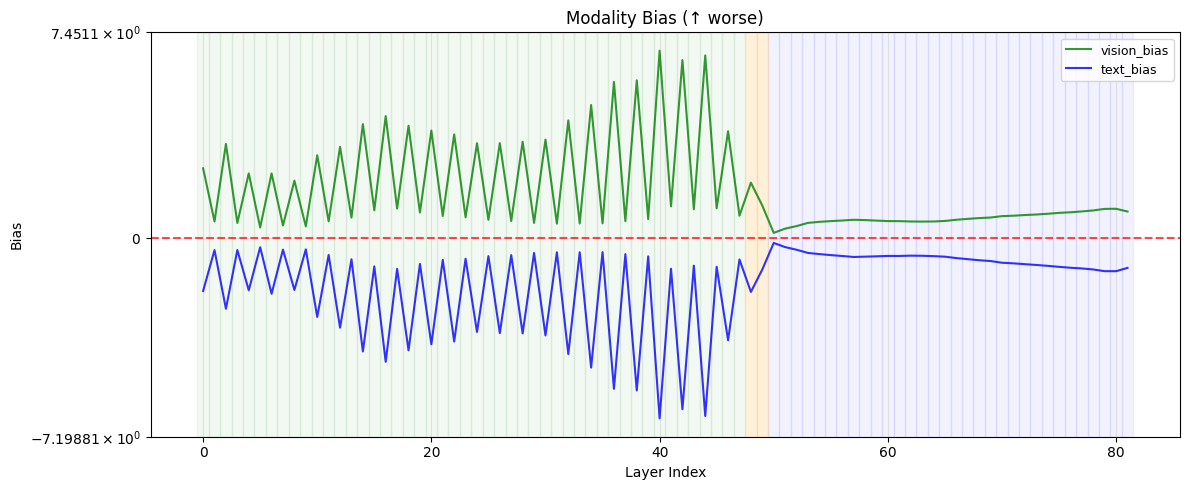

In [5]:
# Plot bias scores
bias.plot(scores)


In [6]:
# Cleanup
bias.cleanup()
del model
torch.cuda.empty_cache()


# Load Saved Results (After Running Jobs)

After running `jobs/bias_layer/run.sh`, use the cells below to load aggregated results with error bars.


In [7]:
# Setup for loading saved results
import os, sys, torch
from argparse import Namespace

repo_root = "/scratch/jq2uw/MME/instruct_vlm_edit"
os.chdir(repo_root)
sys.path.append(repo_root) if repo_root not in sys.path else None

from revlm.config_utils import configure_args
from revlm.editors.auto_q import BiasLayer


In [10]:
# Load aggregated results from saved runs (with error bars)
model_name = "qwen3_4b"  # Options: "blip", "llava", "qwen3", "qwen3_4b"
pool_method = "mean"     # Options: "mean", "last"

args = Namespace(config="revlm/config/config.yaml", editor="ike_chain", model_name=model_name,
                 dataset_name="aokvqa", task="mc", batch_size=1, split="all",
                 rationale=False, cot=False)
args.device = torch.device("cpu")
config = configure_args(args, config_path=args.config)

# Create BiasLayer just for loading (no model needed)
bias_loader = BiasLayer.__new__(BiasLayer)
bias_loader.config = config
bias_loader.device = args.device
bias_loader.pool_method = pool_method
# Load aggregated results
agg_scores = bias_loader.load_results_k(out_dir="results/auto_q_ckpts/bias_layer")
if agg_scores:
    print(f"Loaded {len(agg_scores)} layers")


Task evaluation metrics will be saved to results/te/ike_chain/Qwen3-VL-4B-Instruct/aokvqa
Edit evaluation metrics will be saved to results/ee/ike_chain/Qwen3-VL-4B-Instruct/aokvqa
Predictions will be saved to results/pred/Qwen3-VL-4B-Instruct/aokvqa
Post-edit predictions will be saved to results/pred_postedit/ike_chain/Qwen3-VL-4B-Instruct/aokvqa
Unified filename to save: mc_all.json
[BiasLayer] Loading 10 runs...
[BiasLayer] Aggregated 10 runs, 92 layers
Loaded 92 layers


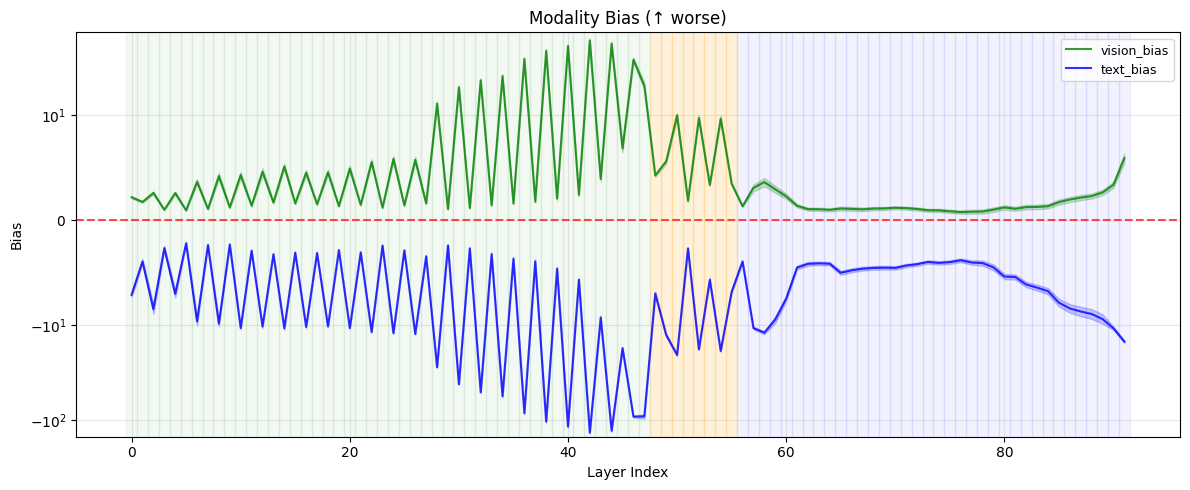

In [11]:
# Plot aggregated results with error bars
if agg_scores:
    bias_loader._classify_layers = lambda layers: BiasLayer._classify_layers(bias_loader, layers)
    bias_loader.plot = lambda scores, **kwargs: BiasLayer.plot(bias_loader, scores, **kwargs)
    bias_loader.plot(agg_scores)
else:
    print("No saved results found. Run jobs/bias_layer/run.sh first.")
